In [1]:
import numpy as np
import jax
import jax.numpy as jnp
from jax import jacfwd
from jax import jit
from jax import vmap
import emcee
import h5py
import corner
import matplotlib.pyplot as plt
import corner
import VBMicrolensing
VBM = VBMicrolensing.VBMicrolensing()
import tqdm
import math
import sys
sys.path.append("/moao38_7/nunota/gapmoe/src/gapmoe/")
from gapmoe import gapmoe
gapmoe_model = gapmoe(rhos_path="../test_data/hist_D.dat",mass_path="../test_data/hist_M.dat",mu_path="../test_data/hist_murel.dat")
gapmoe_model.set_data()
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.lines import Line2D
JD0 = 2450000

In [2]:
from matplotlib import rcParams
rcParams["font.size"] = 15
rcParams["axes.linewidth"] = 3
rcParams['xtick.top'] = True
rcParams['ytick.right'] = True
rcParams['xtick.direction'] = 'in'
rcParams['ytick.direction'] = 'in'
rcParams['xtick.major.size'] = 10
rcParams['xtick.major.width'] = 1.5
rcParams['xtick.minor.size'] = 5
rcParams['xtick.minor.width'] = 1.5
rcParams['ytick.major.size'] = 10
rcParams['ytick.major.width'] = 1.5
rcParams['ytick.minor.size'] = 5
rcParams['ytick.minor.width'] = 1.5

In [3]:
tref = 10063.874
coords = "17:57:38.03 -28:38:28.53"

VBM.t0_par = tref+JD0
VBM.parallaxsystem = 1
VBM.SetObjectCoordinates(coords)

In [4]:
def mag2flux(mag):
    return 10**(-mag / 2.5)

def flux2mag(flux):
    return -2.5 * np.log10(flux)

def linear_fit(x,y,w):
    w_sum = np.sum(w)
    wxy_sum = np.sum(w*x*y)
    wx_sum = np.sum(w*x)
    wy_sum = np.sum(w*y)
    wxx_sum = np.sum(w*x*x)
    bunbo = w_sum*wxx_sum-wx_sum**2
    a = (w_sum*wxy_sum-wx_sum*wy_sum)/bunbo
    b = (wxx_sum*wy_sum-wx_sum*wxy_sum)/bunbo
    y_fit = a * x + b
    chi2 = np.sum(w * (y - y_fit) ** 2)
    return a,b,chi2

cVIBoya = 0.50141358
dVIBoya = 0.41968496
EVI, AI = 1.483,  1.822
def calc_thS(_fs_I,_fs_v):
    I_S = flux2mag(_fs_I)
    V_S = flux2mag(_fs_v)
    VI_S = V_S - I_S
    
    I0_S = I_S - AI
    VI0_S = VI_S - EVI
    
    _theta_star  = 0.5*10**(cVIBoya + dVIBoya*VI0_S  - 0.2*I0_S)
    return _theta_star

def get_pr(theta):
    _t0,_tE,_u0,_q,_s,_theta,_rho = theta[0],theta[1],theta[2],theta[3],theta[4],theta[5],theta[6]
    _piEN, _piEE,_gamma1, _gamma2, _gamma3 = theta[7],theta[8],theta[9],theta[10],theta[11]
    _pr = [math.log(_s), math.log(_q), _u0, _theta, math.log(_rho), math.log(_tE), _t0+JD0, _piEN, _piEE, _gamma1,_gamma2,_gamma3]
    return _pr

def get_pr_wo_lom(theta):
    _t0,_tE,_u0,_q,_s,_theta,_rho = theta[0],theta[1],theta[2],theta[3],theta[4],theta[5],theta[6]
    _piEN, _piEE = theta[7],theta[8]
    _pr = [math.log(_s), math.log(_q), _u0, _theta, math.log(_rho), math.log(_tE), _t0+JD0, _piEN, _piEE]
    return _pr

def get_pr_wo_para(theta):
    _t0,_tE,_u0,_q,_s,_theta,_rho = theta[0],theta[1],theta[2],theta[3],theta[4],theta[5],theta[6]
    _pr = [math.log(_s), math.log(_q), _u0, _theta, math.log(_rho), math.log(_tE), _t0+JD0]
    return _pr

In [5]:
loaded = np.load("../simu_data/simu_data_02.npz", allow_pickle=True)

simu_data = {k: loaded[k] for k in loaded.files}

In [6]:
Is = 20 + AI
Vs = 1 + 20 + EVI
fs_I = mag2flux(Is)
fs_V = mag2flux(Vs)

tE_true = 68.8752
rho_true = 8.9597e-05
s_true = 0.950293
piEN_true = 0.132695
piEE_true = 0.132695
gamma1_true = 0.000702124
gamma2_true = 0.00175532
gamma3_true = 0.00175532

t0_true = 10090 - 5       
u0_true = 0.01          
q_true = 0.005
alpha_true = 3.75*np.pi/4

pr_true = [math.log(s_true), math.log(q_true), 
           u0_true, alpha_true, math.log(rho_true),
           math.log(tE_true), t0_true+JD0, piEN_true, piEE_true
           , gamma1_true,gamma2_true,gamma3_true]

In [7]:
all_flat_samples = []
all_flat_lnprobs = []
all_flat_blobs = []

burnin = 3000
thin = 20

path = f"../test_result/chain/simu_02_chain.h5"
sampler = emcee.backends.HDFBackend(path)

flat_chain = sampler.get_chain(flat=True, discard=burnin, thin=thin)
flat_lnprob = sampler.get_log_prob(flat=True, discard=burnin, thin=thin)
flat_blob = sampler.get_blobs(flat=True, discard=burnin, thin=thin)

all_flat_samples.append(flat_chain)
all_flat_lnprobs.append(flat_lnprob)
all_flat_blobs.append(flat_blob)

joint_flat_samples = np.concatenate(all_flat_samples, axis=0)
joint_flat_lnprobs = np.concatenate(all_flat_lnprobs, axis=0)
joint_flat_thS = np.concatenate(all_flat_blobs, axis=0)

ind = np.where(joint_flat_lnprobs> -8900)
joint_flat_samples = joint_flat_samples[ind]
joint_flat_lnprobs = joint_flat_lnprobs[ind]
joint_flat_thS = joint_flat_thS[ind]

best_arg_full = np.argmax(joint_flat_lnprobs)
best_params_full = joint_flat_samples[best_arg_full]
best_pr_full = get_pr(best_params_full)

In [8]:
all_flat_samples = []
all_flat_lnprobs = []
all_flat_blobs = []

burnin = 3000
thin = 20

path = f"../test_result/chain/wo_gap_simu_02_chain.h5"
sampler = emcee.backends.HDFBackend(path)

flat_chain = sampler.get_chain(flat=True, discard=burnin, thin=thin)
flat_lnprob = sampler.get_log_prob(flat=True, discard=burnin, thin=thin)
flat_blob = sampler.get_blobs(flat=True, discard=burnin, thin=thin)

all_flat_samples.append(flat_chain)
all_flat_lnprobs.append(flat_lnprob)
all_flat_blobs.append(flat_blob)

joint_flat_samples = np.concatenate(all_flat_samples, axis=0)
joint_flat_lnprobs = np.concatenate(all_flat_lnprobs, axis=0)
joint_flat_thS = np.concatenate(all_flat_blobs, axis=0)

ind = np.where(joint_flat_lnprobs> -8900)
joint_flat_samples = joint_flat_samples[ind]
joint_flat_lnprobs = joint_flat_lnprobs[ind]
joint_flat_thS = joint_flat_thS[ind]

best_arg_wo = np.argmax(joint_flat_lnprobs)
best_params_wo = joint_flat_samples[best_arg_wo]
best_pr_wo = get_pr(best_params_wo)

In [9]:
all_flat_samples = []
all_flat_lnprobs = []
all_flat_blobs = []

burnin = 3000
thin = 20

path = f"../test_result/chain/wo_lom_simu_02_chain.h5"
sampler = emcee.backends.HDFBackend(path)

flat_chain = sampler.get_chain(flat=True, discard=burnin, thin=thin)
flat_lnprob = sampler.get_log_prob(flat=True, discard=burnin, thin=thin)
flat_blob = sampler.get_blobs(flat=True, discard=burnin, thin=thin)

all_flat_samples.append(flat_chain)
all_flat_lnprobs.append(flat_lnprob)
all_flat_blobs.append(flat_blob)

joint_flat_samples_wo_lom = np.concatenate(all_flat_samples, axis=0)
joint_flat_lnprobs_wo_lom = np.concatenate(all_flat_lnprobs, axis=0)
joint_flat_thS_wo_lom = np.concatenate(all_flat_blobs, axis=0)

best_arg_wo_lom = np.argmax(joint_flat_lnprobs_wo_lom)
best_params_wo_lom = joint_flat_samples_wo_lom[best_arg_wo_lom]
best_pr_wo_lom = get_pr_wo_lom(best_params_wo_lom)

In [10]:
all_flat_samples = []
all_flat_lnprobs = []
all_flat_blobs = []

burnin = 3000
thin = 20

path = f"../test_result/chain/wo_para_simu_02_chain.h5"
sampler = emcee.backends.HDFBackend(path)

flat_chain = sampler.get_chain(flat=True, discard=burnin, thin=thin)
flat_lnprob = sampler.get_log_prob(flat=True, discard=burnin, thin=thin)
flat_blob = sampler.get_blobs(flat=True, discard=burnin, thin=thin)

all_flat_samples.append(flat_chain)
all_flat_lnprobs.append(flat_lnprob)
all_flat_blobs.append(flat_blob)

joint_flat_samples_wo_para = np.concatenate(all_flat_samples, axis=0)
joint_flat_lnprobs_wo_para = np.concatenate(all_flat_lnprobs, axis=0)
joint_flat_thS_wo_para = np.concatenate(all_flat_blobs, axis=0)

best_arg_wo_para = np.argmax(joint_flat_lnprobs_wo_para)
best_params_wo_para = joint_flat_samples_wo_para[best_arg_wo_para]
best_pr_wo_para = get_pr_wo_para(best_params_wo_para)

In [11]:
best_pr_wo_para

[-0.04389004787793425,
 -5.359984502851435,
 np.float64(0.009125225366887037),
 np.float64(2.916274888673311),
 -9.380828658437489,
 4.35936813544587,
 np.float64(2460085.0701935166)]

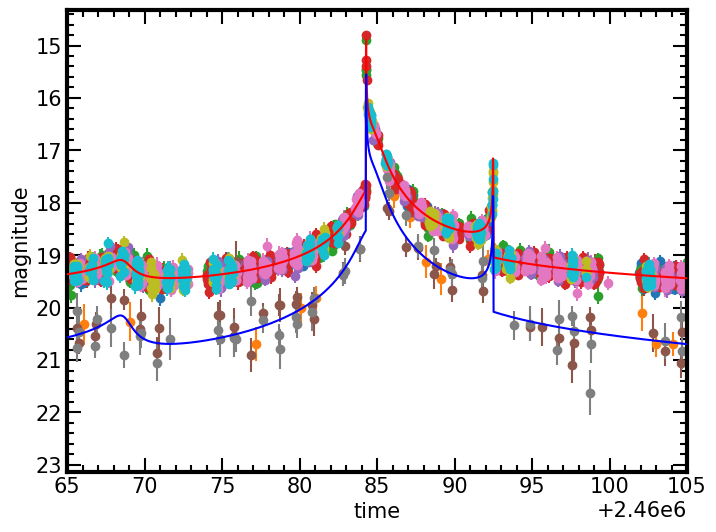

In [12]:
plt.figure(figsize=(8,6))
t_plot = np.linspace(JD0+10065,JD0+10105,10000)
amp_plot = np.array(VBM.BinaryLightCurveOrbital(pr_true, t_plot)[0])
mag_plot_I = flux2mag(amp_plot * fs_I + mag2flux(20))
mag_plot_V = flux2mag(amp_plot * fs_V + mag2flux(22))
plt.plot(t_plot,mag_plot_I,c="red",zorder=10)
plt.plot(t_plot,mag_plot_V,c="blue",zorder=10)

for name in simu_data.keys():
    plt.errorbar(simu_data[name]["time"]+JD0, simu_data[name]["mag_obs"], simu_data[name]["merr"],fmt="o")

plt.xlim(JD0+10065,JD0+10105)
plt.minorticks_on()
plt.gca().invert_yaxis()

plt.xlabel("time")
plt.ylabel("magnitude")
plt.show()

In [13]:
color_map = {
    "MOA_Red": "cyan",
    "KMT-A_I": "blue",
    "KMT-C_I": "red",
    "KMT-S_I": "lightgreen",
}

color_map = {
    "MOA_Red": "C0",
    "KMT-A_I": "C1",
    "KMT-C_I": "C2",
    "KMT-S_I": "C3",
}

def classify_dataset(name):
    if "MOA_Red" in name:
        return "MOA_Red"
    elif "MOA_V" in name:
        return "MOA_V"
    elif "KMT-A" in name and "_I" in name:
        return "KMT-A_I"
    elif "KMT-A" in name and "_V" in name:
        return "KMT-A_V"
    elif "KMT-C" in name and "_I" in name:
        return "KMT-C_I"
    elif "KMT-C" in name and "_V" in name:
        return "KMT-C_V"
    elif "KMT-S" in name and "_I" in name:
        return "KMT-S_I"
    elif "KMT-S" in name and "_V" in name:
        return "KMT-S_V"
    else:
        return "other"

In [14]:
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["DejaVu Serif"],  # デフォルトで matplotlib に入ってる serif フォント
    "mathtext.fontset": "cm",        # 数式を LaTeX っぽく
    "axes.labelsize": 14,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "legend.fontsize": 13,
})

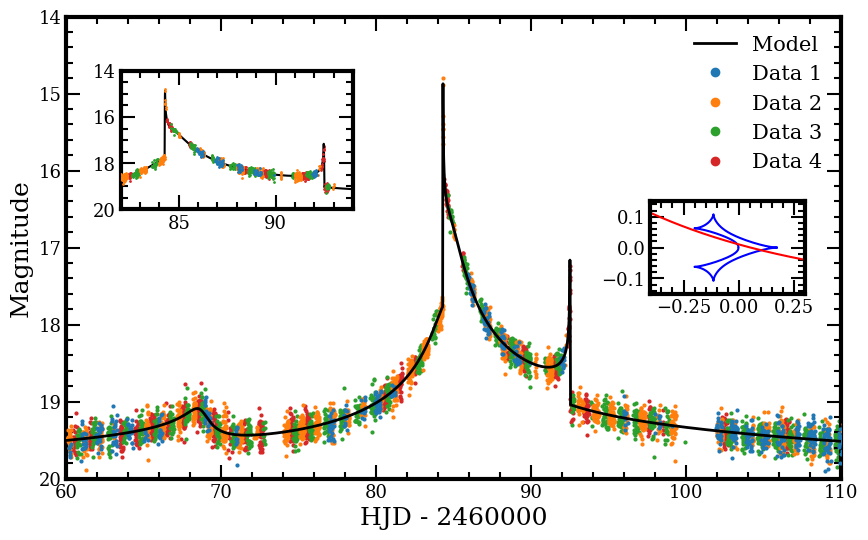

In [27]:
t_plot = np.linspace(JD0+10035,JD0+10110,10000)
amp_plot = np.array(VBM.BinaryLightCurveOrbital(pr_true, t_plot)[0])
mag_plot_I = flux2mag(amp_plot * fs_I + mag2flux(20))
mag_plot_V = flux2mag(amp_plot * fs_V + mag2flux(22))

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(t_plot - JD0 - 10000, mag_plot_I, c="black", label="Model (I)", lw=2, zorder=10)

for i,name in enumerate(simu_data.keys()):
    group = classify_dataset(name)
    color = color_map.get(group, "gray")
    if "V" in name:
        continue
#     ax.errorbar(
#         simu_data[name]["time"] - 10000,
#         simu_data[name]["mag_obs"],
#         simu_data[name]["merr"],
#         fmt="o",
#         color=color,
#         markersize=4,
#         capsize=2,
#         alpha=1,
#         zorder=5-i
#     )
    ax.scatter(
        simu_data[name]["time"] - 10000,
        simu_data[name]["mag_obs"],
        color=color,
        s=4,
        alpha=1,
        zorder=5-i
    )

ax.set_xlim(60, 110)
ax.set_ylim(14, 20)
ax.set_xlabel("HJD - 2460000", fontsize=18)
ax.set_ylabel("Magnitude", fontsize=18)
ax.invert_yaxis()
ax.minorticks_on()

custom_legend = [
    Line2D([0], [0], color="black", lw=2, label="Model"),
    Line2D([0], [0], marker='o', color="C0", linestyle='None', label="Data 1"),
    Line2D([0], [0], marker='o', color="C1", linestyle='None', label="Data 2"),
    Line2D([0], [0], marker='o', color="C2", linestyle='None', label="Data 3"),
    Line2D([0], [0], marker='o', color="C3", linestyle='None', label="Data 4"),
]

ax.legend(handles=custom_legend, fontsize=15, frameon=False, loc="upper right")

axins = inset_axes(ax, width="30%", height="30%", loc="upper left", borderpad=3)
axins.plot(t_plot - JD0 - 10000, mag_plot_I, c="black", lw=1.5, zorder=0)

for i,name in enumerate(simu_data.keys()):
    group = classify_dataset(name)
    color = color_map.get(group, "gray")
    if "V" in name:
        continue
    times = simu_data[name]["time"] - 10000
    mags = simu_data[name]["mag_obs"]
    errs = simu_data[name]["merr"]

    mask = (times >= 82) & (times <= 93) & (mags >= 14) & (mags <= 20)
    if np.any(mask):
#         axins.errorbar(
#             times[mask],
#             mags[mask],
#             errs[mask],
#             fmt="o",
#             color=color,
#             markersize=1,
#             capsize=1,
#             alpha=1,
#             zorder=8-i
#         )
        axins.scatter(
            times[mask],
            mags[mask],
            color=color,
            s=1,
            alpha=1,
            zorder=8-i
        )

axins.set_xlim(82, 94)
axins.set_ylim(20, 14)

axins.minorticks_on()

ax_cau = inset_axes(ax, width="20%", height="20%", loc="center right", borderpad=2)

_, y1, y2, sorb = VBM.BinaryLightCurveOrbital(pr_true, t_plot)
caustictimes = [5180]
colors = [(0, 0, 1, 1), "y", (0.6, 0, 0.4, 1)]

for i in range(1):
    caustics = VBM.Caustics(sorb[caustictimes[i]], best_params_full[3])
    for cau in caustics:
        ax_cau.plot(cau[0], cau[1], color=colors[i])

ax_cau.plot(y1, y2, "red")

ax_cau.set_xlim(-0.4, 0.3)
ax_cau.set_ylim(-0.15, 0.15)
ax_cau.minorticks_on()

plt.savefig("../test_figures/simu_02_lc.pdf")

plt.show()

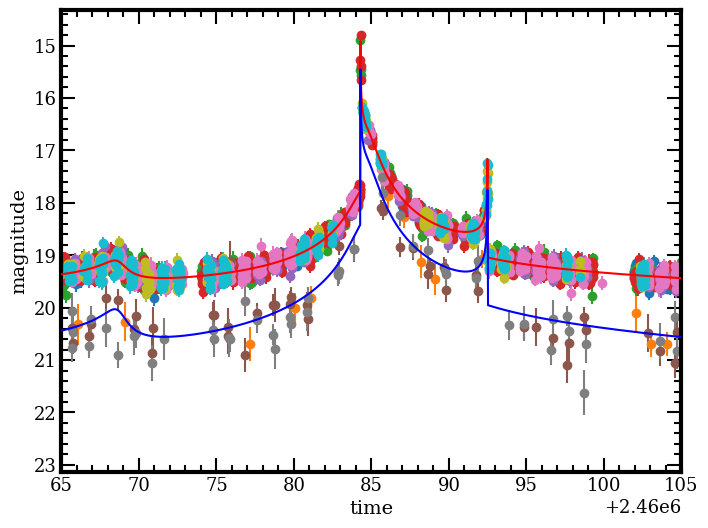

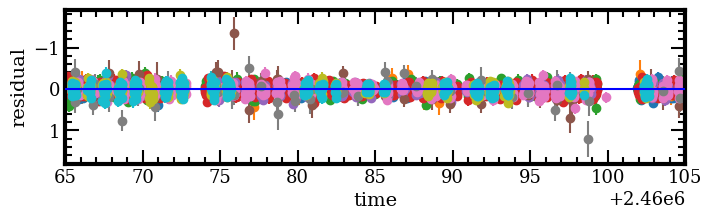

In [16]:
plt.figure(figsize=(8,6))
t_plot = np.linspace(JD0+10065,JD0+10105,10000)
amp_plot = np.array(VBM.BinaryLightCurveOrbital(best_pr_full, t_plot)[0])

_model_amp_I = np.array(VBM.BinaryLightCurveOrbital(best_pr_full,simu_data["MOA_Red"]["time"]+JD0)[0])
_model_amp_V = np.array(VBM.BinaryLightCurveOrbital(best_pr_full,simu_data["MOA_V"]["time"]+JD0)[0])
_fs_I,_fb_I,_ = linear_fit(_model_amp_I,simu_data["MOA_Red"]["flux_obs"],simu_data["MOA_Red"]["ferr"]**(-2))
_fs_V,_fb_V,_ = linear_fit(_model_amp_V,simu_data["MOA_V"]["flux_obs"],simu_data["MOA_V"]["ferr"]**(-2))

mag_plot_I = flux2mag(amp_plot * _fs_I + _fb_I)
mag_plot_V = flux2mag(amp_plot * _fs_V + _fb_V)

plt.plot(t_plot,mag_plot_I,c="red",zorder=10)
plt.plot(t_plot,mag_plot_V,c="blue",zorder=10)

for name in simu_data.keys():
    plt.errorbar(simu_data[name]["time"]+JD0, simu_data[name]["mag_obs"], simu_data[name]["merr"],fmt="o")

plt.xlim(JD0+10065,JD0+10105)
plt.minorticks_on()
plt.gca().invert_yaxis()

plt.xlabel("time")
plt.ylabel("magnitude")

plt.show()

plt.figure(figsize=(8,2))

for name in simu_data.keys():
    _model_amp = np.array(VBM.BinaryLightCurveOrbital(best_pr_full,simu_data[name]["time"]+JD0)[0])
    _fs,_fb,_ = linear_fit(_model_amp,simu_data[name]["flux_obs"],simu_data[name]["ferr"]**(-2))
    mag_model = flux2mag(_model_amp * _fs + _fb)
    
    plt.errorbar(simu_data[name]["time"]+JD0, simu_data[name]["mag_obs"]-mag_model, simu_data[name]["merr"],fmt="o")
    
plt.plot(t_plot,mag_plot_I-mag_plot_I,c="blue",zorder=10)
    
plt.xlim(JD0+10065,JD0+10105)
plt.minorticks_on()
plt.gca().invert_yaxis()
plt.xlabel("time")
plt.ylabel("residual")
plt.show()

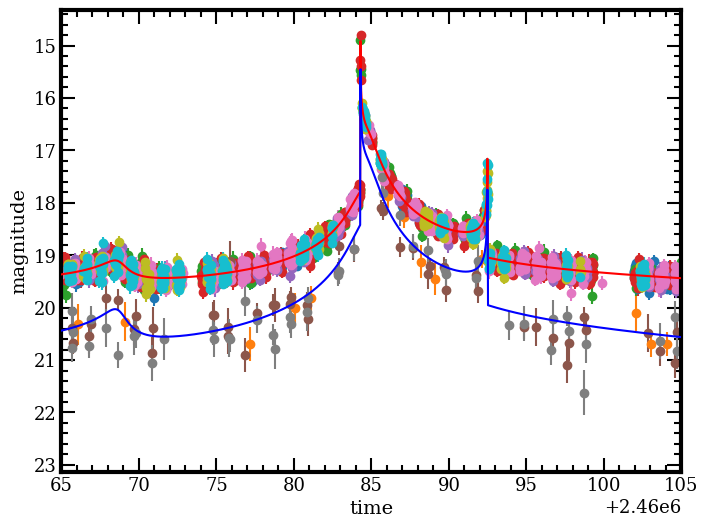

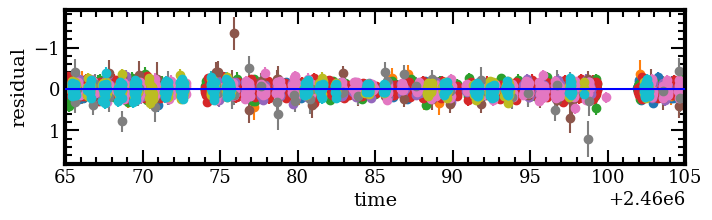

In [17]:
plt.figure(figsize=(8,6))

t_plot = np.linspace(JD0+10065,JD0+10105,10000)
amp_plot = np.array(VBM.BinaryLightCurveOrbital(best_pr_wo, t_plot)[0])

_model_amp_I = np.array(VBM.BinaryLightCurveOrbital(best_pr_wo,simu_data["MOA_Red"]["time"]+JD0)[0])
_model_amp_V = np.array(VBM.BinaryLightCurveOrbital(best_pr_wo,simu_data["MOA_V"]["time"]+JD0)[0])

_fs_I,_fb_I,_ = linear_fit(_model_amp_I,simu_data["MOA_Red"]["flux_obs"],simu_data["MOA_Red"]["ferr"]**(-2))
_fs_V,_fb_V,_ = linear_fit(_model_amp_V,simu_data["MOA_V"]["flux_obs"],simu_data["MOA_V"]["ferr"]**(-2))

mag_plot_I = flux2mag(amp_plot * _fs_I + _fb_I)
mag_plot_V = flux2mag(amp_plot * _fs_V + _fb_V)

plt.plot(t_plot,mag_plot_I,c="red",zorder=10)
plt.plot(t_plot,mag_plot_V,c="blue",zorder=10)

for name in simu_data.keys():
    plt.errorbar(simu_data[name]["time"]+JD0, simu_data[name]["mag_obs"], simu_data[name]["merr"],fmt="o")

plt.xlim(JD0+10065,JD0+10105)
plt.minorticks_on()
plt.gca().invert_yaxis()

plt.xlabel("time")
plt.ylabel("magnitude")

plt.show()

plt.figure(figsize=(8,2))

for name in simu_data.keys():
    _model_amp = np.array(VBM.BinaryLightCurveOrbital(best_pr_wo,simu_data[name]["time"]+JD0)[0])
    _fs,_fb,_ = linear_fit(_model_amp,simu_data[name]["flux_obs"],simu_data[name]["ferr"]**(-2))
    mag_model = flux2mag(_model_amp * _fs + _fb)
    
    plt.errorbar(simu_data[name]["time"]+JD0, simu_data[name]["mag_obs"]-mag_model, simu_data[name]["merr"],fmt="o")
    
plt.plot(t_plot,mag_plot_I-mag_plot_I,c="blue",zorder=10)
    
plt.xlim(JD0+10065,JD0+10105)
plt.minorticks_on()
plt.gca().invert_yaxis()
plt.xlabel("time")
plt.ylabel("residual")
plt.show()

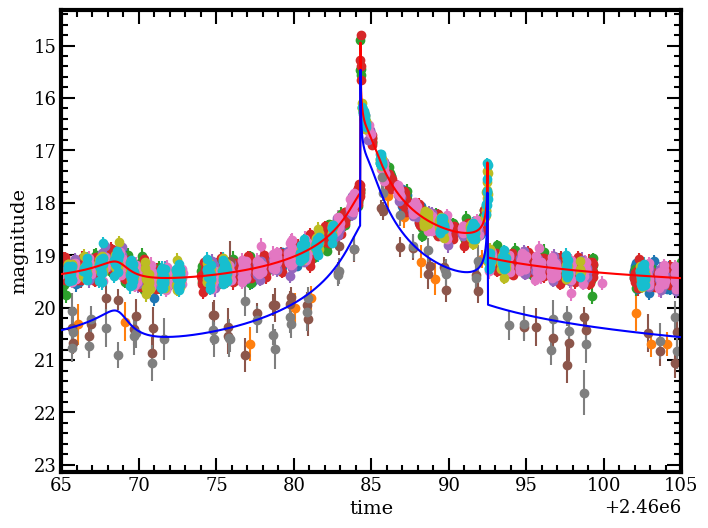

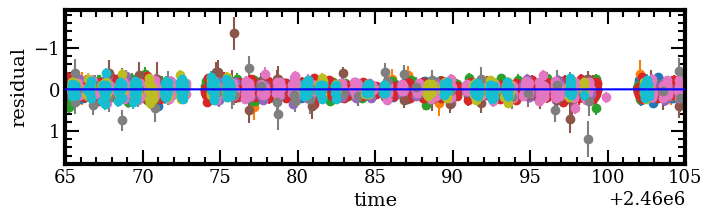

In [18]:
plt.figure(figsize=(8,6))

t_plot = np.linspace(JD0+10065,JD0+10105,10000)
amp_plot = np.array(VBM.BinaryLightCurveParallax(best_pr_wo_lom, t_plot)[0])

_model_amp_I = np.array(VBM.BinaryLightCurveParallax(best_pr_wo_lom,simu_data["MOA_Red"]["time"]+JD0)[0])
_model_amp_V = np.array(VBM.BinaryLightCurveParallax(best_pr_wo_lom,simu_data["MOA_V"]["time"]+JD0)[0])

_fs_I,_fb_I,_ = linear_fit(_model_amp_I,simu_data["MOA_Red"]["flux_obs"],simu_data["MOA_Red"]["ferr"]**(-2))
_fs_V,_fb_V,_ = linear_fit(_model_amp_V,simu_data["MOA_V"]["flux_obs"],simu_data["MOA_V"]["ferr"]**(-2))

mag_plot_I = flux2mag(amp_plot * _fs_I + _fb_I)
mag_plot_V = flux2mag(amp_plot * _fs_V + _fb_V)

plt.plot(t_plot,mag_plot_I,c="red",zorder=10)
plt.plot(t_plot,mag_plot_V,c="blue",zorder=10)

for name in simu_data.keys():
    plt.errorbar(simu_data[name]["time"]+JD0, simu_data[name]["mag_obs"], simu_data[name]["merr"],fmt="o")

plt.xlim(JD0+10065,JD0+10105)
plt.minorticks_on()
plt.gca().invert_yaxis()

plt.xlabel("time")
plt.ylabel("magnitude")

plt.show()

plt.figure(figsize=(8,2))

for name in simu_data.keys():
    _model_amp = np.array(VBM.BinaryLightCurveParallax(best_pr_wo_lom,simu_data[name]["time"]+JD0)[0])
    _fs,_fb,_ = linear_fit(_model_amp,simu_data[name]["flux_obs"],simu_data[name]["ferr"]**(-2))
    mag_model = flux2mag(_model_amp * _fs + _fb)
    
    plt.errorbar(simu_data[name]["time"]+JD0, simu_data[name]["mag_obs"]-mag_model, simu_data[name]["merr"],fmt="o")
    
plt.plot(t_plot,mag_plot_I-mag_plot_I,c="blue",zorder=10)
    
plt.xlim(JD0+10065,JD0+10105)
plt.minorticks_on()
plt.gca().invert_yaxis()
plt.xlabel("time")
plt.ylabel("residual")
plt.show()

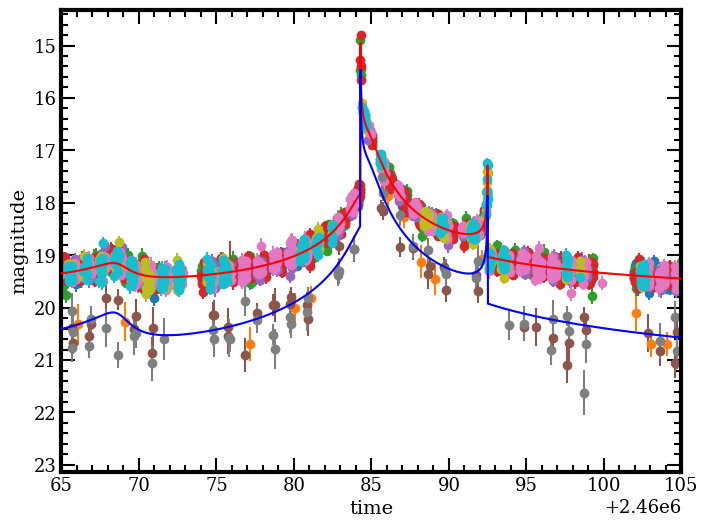

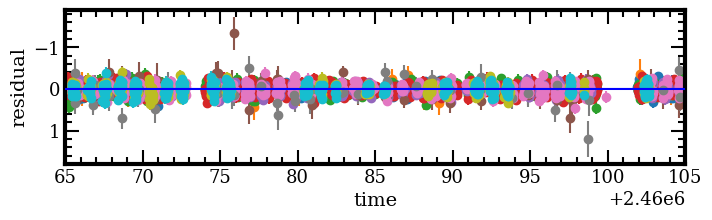

In [19]:
plt.figure(figsize=(8,6))

t_plot = np.linspace(JD0+10065,JD0+10105,10000)
amp_plot = np.array(VBM.BinaryLightCurve(best_pr_wo_para, t_plot)[0])

_model_amp_I = np.array(VBM.BinaryLightCurve(best_pr_wo_para,simu_data["MOA_Red"]["time"]+JD0)[0])
_model_amp_V = np.array(VBM.BinaryLightCurve(best_pr_wo_para,simu_data["MOA_V"]["time"]+JD0)[0])

_fs_I,_fb_I,_ = linear_fit(_model_amp_I,simu_data["MOA_Red"]["flux_obs"],simu_data["MOA_Red"]["ferr"]**(-2))
_fs_V,_fb_V,_ = linear_fit(_model_amp_V,simu_data["MOA_V"]["flux_obs"],simu_data["MOA_V"]["ferr"]**(-2))

mag_plot_I = flux2mag(amp_plot * _fs_I + _fb_I)
mag_plot_V = flux2mag(amp_plot * _fs_V + _fb_V)

plt.plot(t_plot,mag_plot_I,c="red",zorder=10)
plt.plot(t_plot,mag_plot_V,c="blue",zorder=10)

for name in simu_data.keys():
    plt.errorbar(simu_data[name]["time"]+JD0, simu_data[name]["mag_obs"], simu_data[name]["merr"],fmt="o")

plt.xlim(JD0+10065,JD0+10105)
plt.minorticks_on()
plt.gca().invert_yaxis()

plt.xlabel("time")
plt.ylabel("magnitude")

plt.show()

plt.figure(figsize=(8,2))

for name in simu_data.keys():
    _model_amp = np.array(VBM.BinaryLightCurve(best_pr_wo_para,simu_data[name]["time"]+JD0)[0])
    _fs,_fb,_ = linear_fit(_model_amp,simu_data[name]["flux_obs"],simu_data[name]["ferr"]**(-2))
    mag_model = flux2mag(_model_amp * _fs + _fb)
    
    plt.errorbar(simu_data[name]["time"]+JD0, simu_data[name]["mag_obs"]-mag_model, simu_data[name]["merr"],fmt="o")
    
plt.plot(t_plot,mag_plot_I-mag_plot_I,c="blue",zorder=10)
    
plt.xlim(JD0+10065,JD0+10105)
plt.minorticks_on()
plt.gca().invert_yaxis()
plt.xlabel("time")
plt.ylabel("residual")
plt.show()

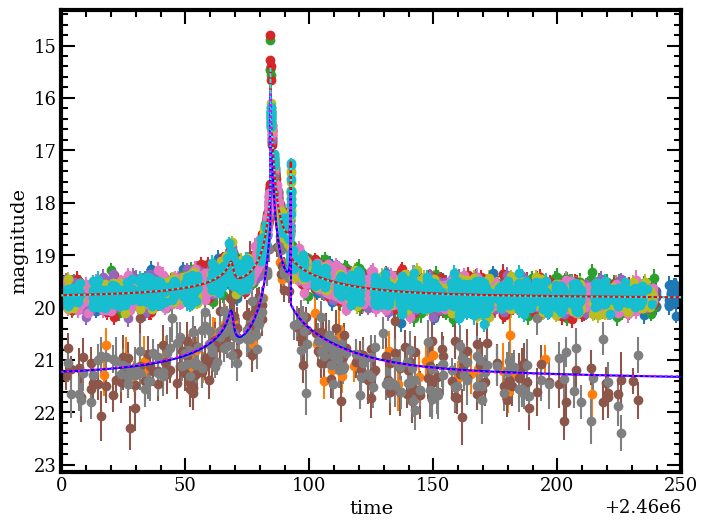

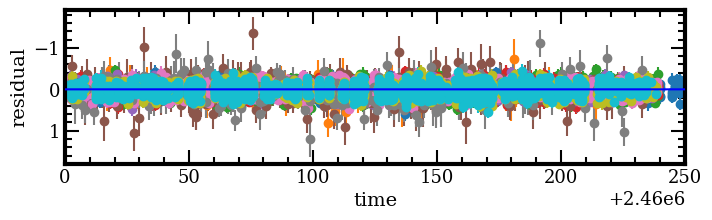

In [20]:
plt.figure(figsize=(8,6))


#========================================================================#
t_plot = np.linspace(JD0+10000,JD0+10250,10000)
amp_plot = np.array(VBM.BinaryLightCurveParallax(best_pr_wo_lom, t_plot)[0])

_model_amp_I = np.array(VBM.BinaryLightCurveParallax(best_pr_wo_lom,simu_data["MOA_Red"]["time"]+JD0)[0])
_model_amp_V = np.array(VBM.BinaryLightCurveParallax(best_pr_wo_lom,simu_data["MOA_V"]["time"]+JD0)[0])

_fs_I,_fb_I,_ = linear_fit(_model_amp_I,simu_data["MOA_Red"]["flux_obs"],simu_data["MOA_Red"]["ferr"]**(-2))
_fs_V,_fb_V,_ = linear_fit(_model_amp_V,simu_data["MOA_V"]["flux_obs"],simu_data["MOA_V"]["ferr"]**(-2))

mag_plot_I = flux2mag(amp_plot * _fs_I + _fb_I)
mag_plot_V = flux2mag(amp_plot * _fs_V + _fb_V)

plt.plot(t_plot,mag_plot_I,c="red",zorder=10)
plt.plot(t_plot,mag_plot_V,c="blue",zorder=10)
#========================================================================#
#========================================================================#
t_plot = np.linspace(JD0+10000,JD0+10250,10000)
amp_plot = np.array(VBM.BinaryLightCurve(best_pr_wo_para, t_plot)[0])

_model_amp_I = np.array(VBM.BinaryLightCurve(best_pr_wo_para,simu_data["MOA_Red"]["time"]+JD0)[0])
_model_amp_V = np.array(VBM.BinaryLightCurve(best_pr_wo_para,simu_data["MOA_V"]["time"]+JD0)[0])

_fs_I,_fb_I,_ = linear_fit(_model_amp_I,simu_data["MOA_Red"]["flux_obs"],simu_data["MOA_Red"]["ferr"]**(-2))
_fs_V,_fb_V,_ = linear_fit(_model_amp_V,simu_data["MOA_V"]["flux_obs"],simu_data["MOA_V"]["ferr"]**(-2))

mag_plot_I = flux2mag(amp_plot * _fs_I + _fb_I)
mag_plot_V = flux2mag(amp_plot * _fs_V + _fb_V)

plt.plot(t_plot,mag_plot_I,c="cyan",zorder=10,linestyle=":")
plt.plot(t_plot,mag_plot_V,c="magenta",zorder=10,linestyle=":")
#========================================================================#

for name in simu_data.keys():
    plt.errorbar(simu_data[name]["time"]+JD0, simu_data[name]["mag_obs"], simu_data[name]["merr"],fmt="o")

plt.xlim(JD0+10000,JD0+10250)
plt.minorticks_on()
plt.gca().invert_yaxis()

plt.xlabel("time")
plt.ylabel("magnitude")

plt.show()

plt.figure(figsize=(8,2))

for name in simu_data.keys():
    _model_amp = np.array(VBM.BinaryLightCurveParallax(best_pr_wo_lom,simu_data[name]["time"]+JD0)[0])
    _fs,_fb,_ = linear_fit(_model_amp,simu_data[name]["flux_obs"],simu_data[name]["ferr"]**(-2))
    mag_model = flux2mag(_model_amp * _fs + _fb)
    
    plt.errorbar(simu_data[name]["time"]+JD0, simu_data[name]["mag_obs"]-mag_model, simu_data[name]["merr"],fmt="o")
    
plt.plot(t_plot,mag_plot_I-mag_plot_I,c="blue",zorder=10)

    
plt.xlim(JD0+10000,JD0+10250)
plt.minorticks_on()
plt.gca().invert_yaxis()
plt.xlabel("time")
plt.ylabel("residual")
plt.show()

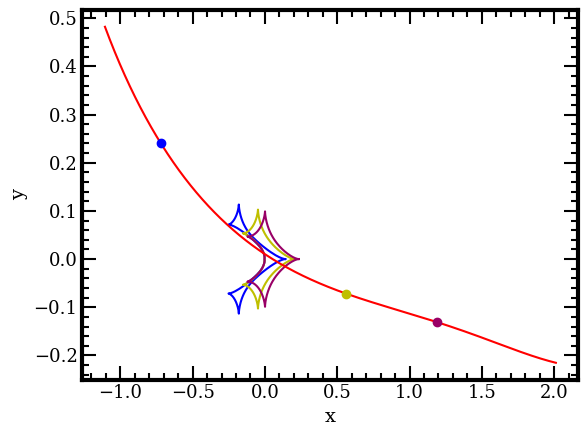

In [21]:
_,y1, y2 ,sorb= VBM.BinaryLightCurveOrbital(pr_true,t_plot) 

caustictimes = [1300,5000,7000]
colors = [(0,0,1,1),"y",(0.6,0,0.4,1)]
for i in range(0,3):
    caustics = VBM.Caustics(sorb[caustictimes[i]],best_params_full[3])
    for cau in caustics:
        plt.plot(cau[0],cau[1],color = colors[i])
        
plt.plot(y1,y2,"red")
for i in range(0,3):
    plt.plot([y1[caustictimes[i]]],[y2[caustictimes[i]]],color=colors[i],marker="o")

plt.minorticks_on()

plt.xlabel("x")
plt.ylabel("y")
plt.show()

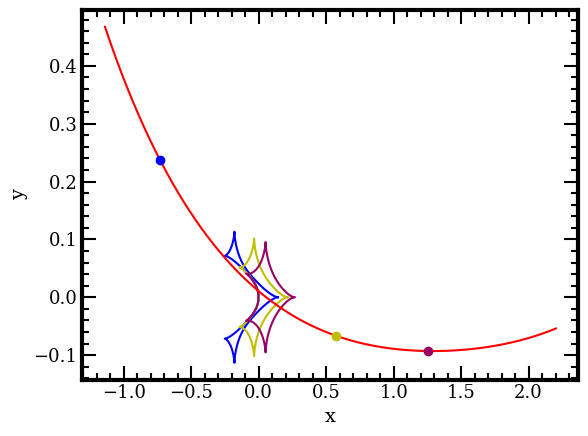

In [22]:
_,y1, y2 ,sorb= VBM.BinaryLightCurveOrbital(best_pr_full,t_plot) 

caustictimes = [1300,5000,7000]
colors = [(0,0,1,1),"y",(0.6,0,0.4,1)]
for i in range(0,3):
    caustics = VBM.Caustics(sorb[caustictimes[i]],best_params_full[3])
    for cau in caustics:
        plt.plot(cau[0],cau[1],color = colors[i])
        
plt.plot(y1,y2,"red")
for i in range(0,3):
    plt.plot([y1[caustictimes[i]]],[y2[caustictimes[i]]],color=colors[i],marker="o")

plt.minorticks_on()

plt.xlabel("x")
plt.ylabel("y")
plt.show()

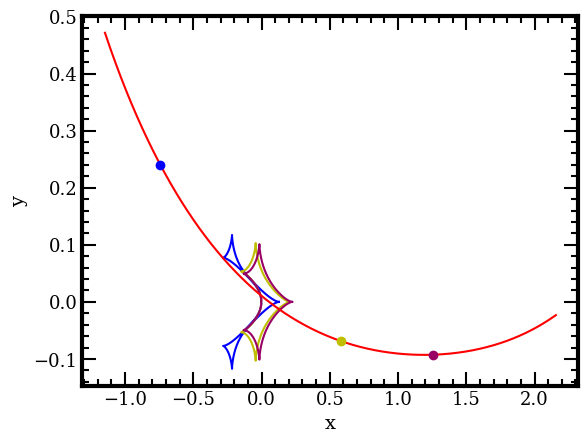

In [23]:
_,y1, y2 ,sorb= VBM.BinaryLightCurveOrbital(best_pr_wo,t_plot) 

caustictimes = [1300,5000,7000]
colors = [(0,0,1,1),"y",(0.6,0,0.4,1)]
for i in range(0,3):
    caustics = VBM.Caustics(sorb[caustictimes[i]],best_params_wo[3])
    for cau in caustics:
        plt.plot(cau[0],cau[1],color = colors[i])
        
plt.plot(y1,y2,"red")
for i in range(0,3):
    plt.plot([y1[caustictimes[i]]],[y2[caustictimes[i]]],color=colors[i],marker="o")

plt.minorticks_on()

plt.xlabel("x")
plt.ylabel("y")
plt.show()

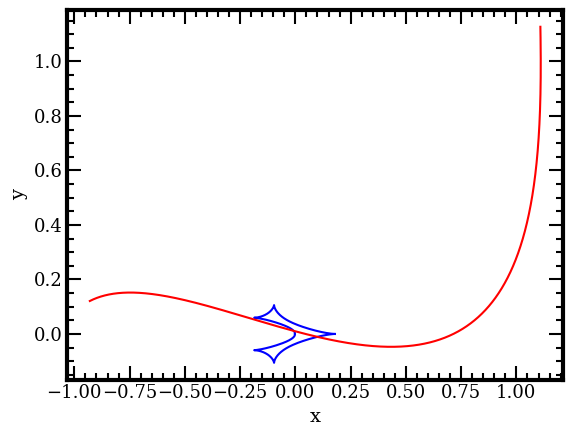

In [24]:
_,y1, y2 = VBM.BinaryLightCurveParallax(best_pr_wo_lom,t_plot) 
caustics = VBM.Caustics(best_params_wo_lom[4],best_params_wo_lom[3])
for cau in caustics:
    plt.plot(cau[0],cau[1],c=(0,0,1,1))
plt.plot(y1,y2,"red")

plt.minorticks_on()

plt.xlabel("x")
plt.ylabel("y")
plt.show()

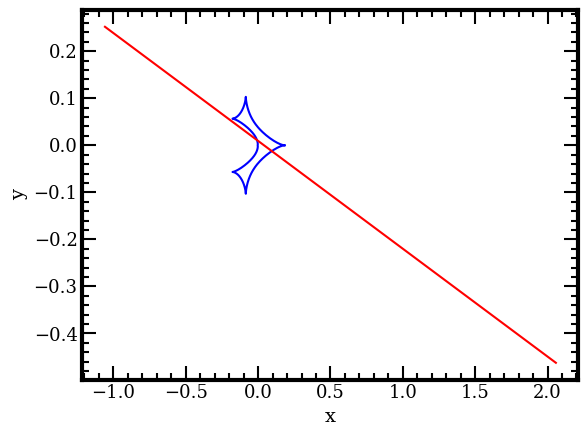

In [25]:
_,y1, y2 = VBM.BinaryLightCurve(best_pr_wo_para,t_plot) 
caustics = VBM.Caustics(best_params_wo_para[4],best_params_wo_para[3])
for cau in caustics:
    plt.plot(cau[0],cau[1],c=(0,0,1,1))
plt.plot(y1,y2,"red")

plt.minorticks_on()

plt.xlabel("x")
plt.ylabel("y")
plt.show()

In [26]:
_chi2 = 0
for name in simu_data.keys():
    _model_amp = np.array(VBM.BinaryLightCurveOrbital(pr_true,simu_data[name]["time"]+JD0)[0])
    _,_,_chi2_tmp = linear_fit(_model_amp,simu_data[name]["flux_obs"],simu_data[name]["ferr"]**(-2))
    _chi2 += _chi2_tmp
print("true solution:     ",_chi2)

_chi2 = 0
for name in simu_data.keys():
    _model_amp = np.array(VBM.BinaryLightCurveOrbital(best_pr_full,simu_data[name]["time"]+JD0)[0])
    _,_,_chi2_tmp = linear_fit(_model_amp,simu_data[name]["flux_obs"],simu_data[name]["ferr"]**(-2))
    _chi2 += _chi2_tmp
print("full solution:       ",_chi2)

_chi2 = 0
for name in simu_data.keys():
    _model_amp = np.array(VBM.BinaryLightCurveOrbital(best_pr_wo,simu_data[name]["time"]+JD0)[0])
    _,_,_chi2_tmp = linear_fit(_model_amp,simu_data[name]["flux_obs"],simu_data[name]["ferr"]**(-2))
    _chi2 += _chi2_tmp
print("wo gap solution: ",_chi2)

_chi2 = 0
for name in simu_data.keys():
    _model_amp = np.array(VBM.BinaryLightCurveParallax(best_pr_wo_lom,simu_data[name]["time"]+JD0)[0])
    _,_,_chi2_tmp = linear_fit(_model_amp,simu_data[name]["flux_obs"],simu_data[name]["ferr"]**(-2))
    _chi2 += _chi2_tmp
print("wo lom solution: ", _chi2)

_chi2 = 0
for name in simu_data.keys():
    _model_amp = np.array(VBM.BinaryLightCurve(best_pr_wo_para,simu_data[name]["time"]+JD0)[0])
    _,_,_chi2_tmp = linear_fit(_model_amp,simu_data[name]["flux_obs"],simu_data[name]["ferr"]**(-2))
    _chi2 += _chi2_tmp
print("wo para solution: ", _chi2)

true solution:      17721.70081701612
full solution:        17714.814191198762
wo gap solution:  17713.63518589508
wo lom solution:  17763.469936063066
wo para solution:  17914.52637390194
